# Task 1

In [4]:
import pandas as pd

# 1. Load the dataset
# Making sure to read the file we just created
df = pd.read_csv("students.csv")

# 2. Display the top few rows to see the data structure
print("--- Top 5 Student Records ---")
print(df.head())

# 3. Check shape and data types (Rows x Columns)
print("\n--- Data Info (Shape & Types) ---")
print(f"Shape: {df.shape}")
print(df.dtypes)

# 4. Basic summary stats for numeric columns
print("\n--- Summary Statistics ---")
print(df.describe())

# 5. Count how many students passed vs failed
print("\n--- Pass/Fail Counts ---")
pass_fail_summary = df['passed'].value_counts()
print(pass_fail_summary)

# 6. Average subject scores for Pass vs Fail
print("\n--- Subject Averages by Outcome ---")
subject_cols = ['math', 'science', 'english', 'history', 'pe']

passing_avgs = df[df['passed'] == 1][subject_cols].mean()
failing_avgs = df[df['passed'] == 0][subject_cols].mean()

print("Average Scores for Passing Students:")
print(passing_avgs)
print("\nAverage Scores for Failing Students:")
print(failing_avgs)

# 7. Finding the top overall student
# We add a temporary column for calculation
df['student_avg'] = df[subject_cols].mean(axis=1)
top_student_idx = df['student_avg'].idxmax()
top_student = df.loc[top_student_idx]

print("\n--- Top Overall Performer ---")
print(f"Name: {top_student['name']}")
print(f"Overall Average: {top_student['student_avg']:.2f}")

--- Top 5 Student Records ---
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

--- Data Info (Shape & Types) ---
Shape: (15, 9)
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

--- Summary Statistics --

# Task 2

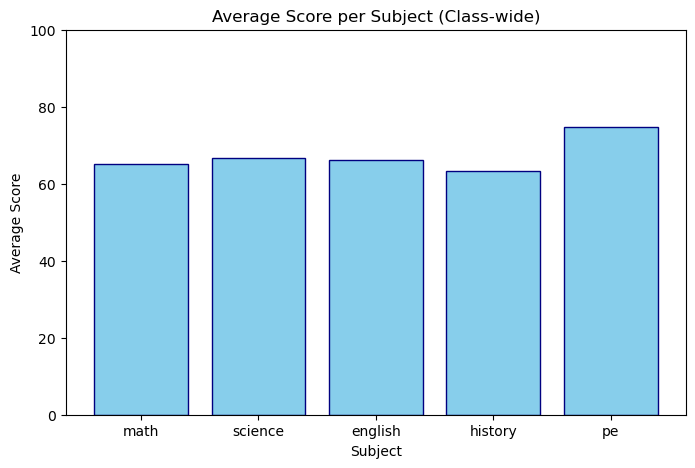

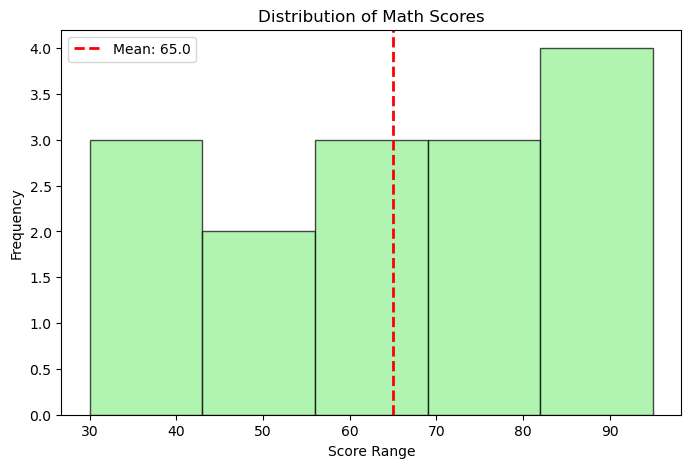

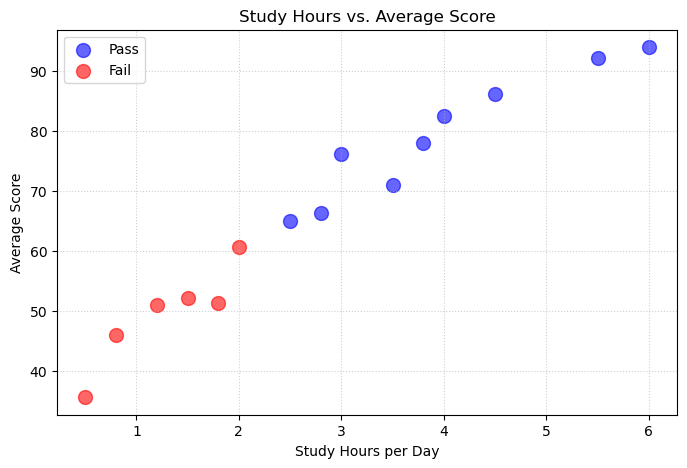

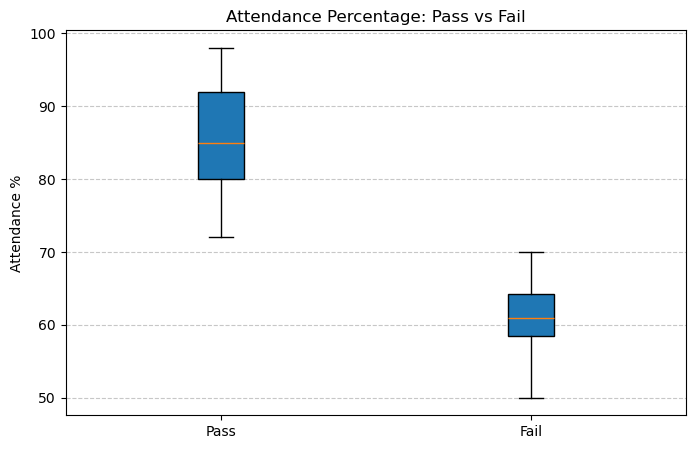

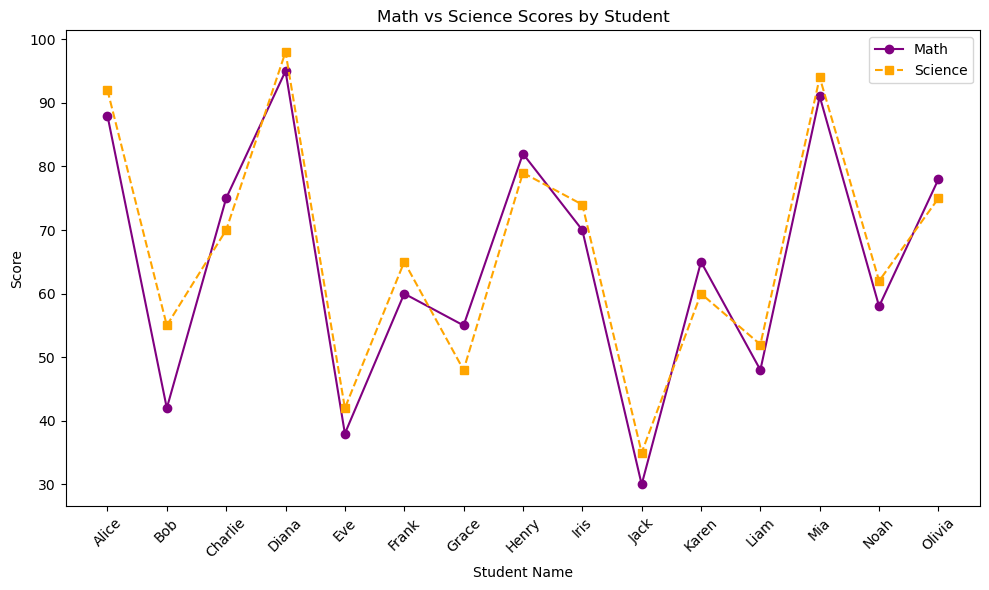

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# 0. Preparation: Add the average score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# 1. Bar Chart: Average Score Per Subject
plt.figure(figsize=(8, 5))
subject_means = df[subject_cols].mean()
plt.bar(subject_means.index, subject_means.values, color='skyblue', edgecolor='navy')
plt.title('Average Score per Subject (Class-wide)')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.ylim(0, 100) # Setting limit for better comparison
plt.savefig('plot1_bar.png')
plt.show()

# 2. Histogram: Distribution of Math Scores
plt.figure(figsize=(8, 5))
math_mean = df['math'].mean()
plt.hist(df['math'], bins=5, color='lightgreen', edgecolor='black', alpha=0.7)
plt.axvline(math_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {math_mean:.1f}')
plt.title('Distribution of Math Scores')
plt.xlabel('Score Range')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('plot2_histogram.png')
plt.show()

# 3. Scatter Plot: Study Hours vs Avg Score
plt.figure(figsize=(8, 5))
pass_group = df[df['passed'] == 1]
fail_group = df[df['passed'] == 0]

plt.scatter(pass_group['study_hours_per_day'], pass_group['avg_score'], 
            color='blue', label='Pass', s=100, alpha=0.6)
plt.scatter(fail_group['study_hours_per_day'], fail_group['avg_score'], 
            color='red', label='Fail', s=100, alpha=0.6)

plt.title('Study Hours vs. Average Score')
plt.xlabel('Study Hours per Day')
plt.ylabel('Average Score')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('plot3_scatter.png')
plt.show()

# 4. Box Plot: Attendance for Pass vs Fail
plt.figure(figsize=(8, 5))
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

# FIX: Change 'labels' to 'tick_labels'
plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Pass', 'Fail'], patch_artist=True)

plt.title('Attendance Percentage: Pass vs Fail')
plt.ylabel('Attendance %')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('plot4_box_fixed.png')
plt.show()

# 5. Line Plot: Math vs Science per Student
plt.figure(figsize=(10, 6))
plt.plot(df['name'], df['math'], marker='o', linestyle='-', label='Math', color='purple')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', label='Science', color='orange')

plt.title('Math vs Science Scores by Student')
plt.xlabel('Student Name')
plt.ylabel('Score')
plt.xticks(rotation=45) # Rotate names to prevent overlap
plt.legend()
plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('plot5_line.png')
plt.show()

# Task 3

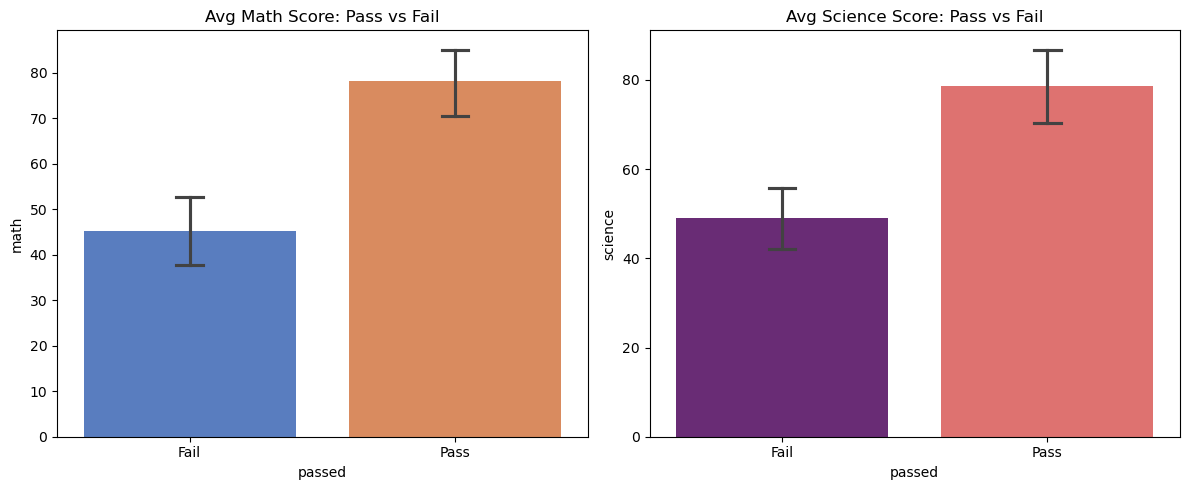

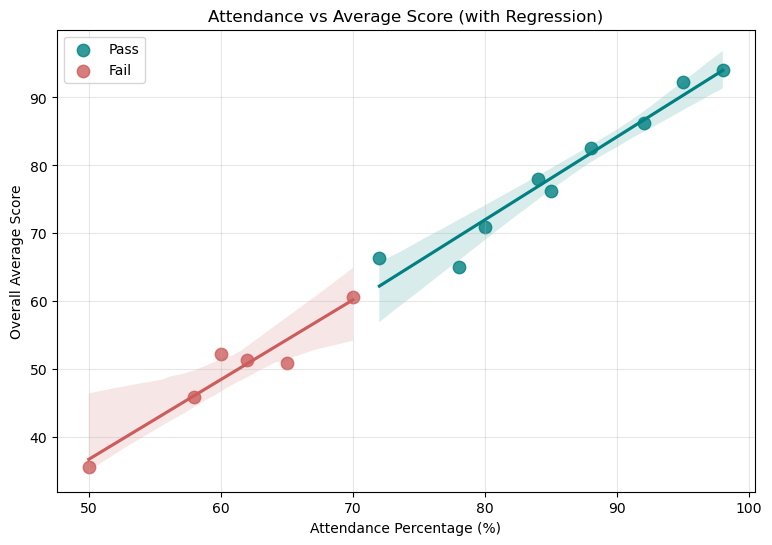

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Bar Plot: Math and Science Averages by Pass/Fail
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# FIX 1: Assign 'hue' to the same variable as 'x' to keep the palette working
# FIX 2: Use ax.set_xticks() before set_xticklabels() to satisfy Matplotlib's FixedLocator
sns.barplot(data=df, x='passed', y='math', hue='passed', ax=ax1, palette='muted', capsize=.1, legend=False)
ax1.set_title('Avg Math Score: Pass vs Fail')
ax1.set_xticks([0, 1]) 
ax1.set_xticklabels(['Fail', 'Pass'])

# Repeat fixes for the Science plot
sns.barplot(data=df, x='passed', y='science', hue='passed', ax=ax2, palette='magma', capsize=.1, legend=False)
ax2.set_title('Avg Science Score: Pass vs Fail')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Fail', 'Pass'])

plt.tight_layout()
plt.savefig('seaborn_bars_updated.png')
plt.show()

# 2. Scatter Plot with Regression Lines
plt.figure(figsize=(9, 6))

# We plot the two groups separately to get individual regression lines
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', 
            label='Pass', color='teal', scatter_kws={'s':80})
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', 
            label='Fail', color='indianred', scatter_kws={'s':80})

plt.title('Attendance vs Average Score (with Regression)')
plt.xlabel('Attendance Percentage (%)')
plt.ylabel('Overall Average Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('seaborn_scatter_reg.png')
plt.show()

###### Comparison Comment:
Seaborn is definitely easier for statistical plots because it handles the aggregation (like means and error bars) 
automatically in the bar charts. However, Matplotlib felt a bit more predictable when I wanted to place two 
different metrics side-by-side using subplots, as Seaborn still relies on Matplotlib's axes objects for layout.

# Task 4

Training Accuracy: 100.0%
Test Accuracy: 100.0%

--- Test Set Predictions ---
Jack     | Actual: 0 | Predicted: 0 | ✅ correct
Liam     | Actual: 0 | Predicted: 0 | ✅ correct
Alice    | Actual: 1 | Predicted: 1 | ✅ correct

--- Feature Coefficients (Sorted by Importance) ---
               Feature    Weight
2              english  0.812513
5       attendance_pct  0.521876
6  study_hours_per_day  0.484433
4                   pe  0.474974
0                 math  0.437944
1              science  0.323010
3              history  0.262929


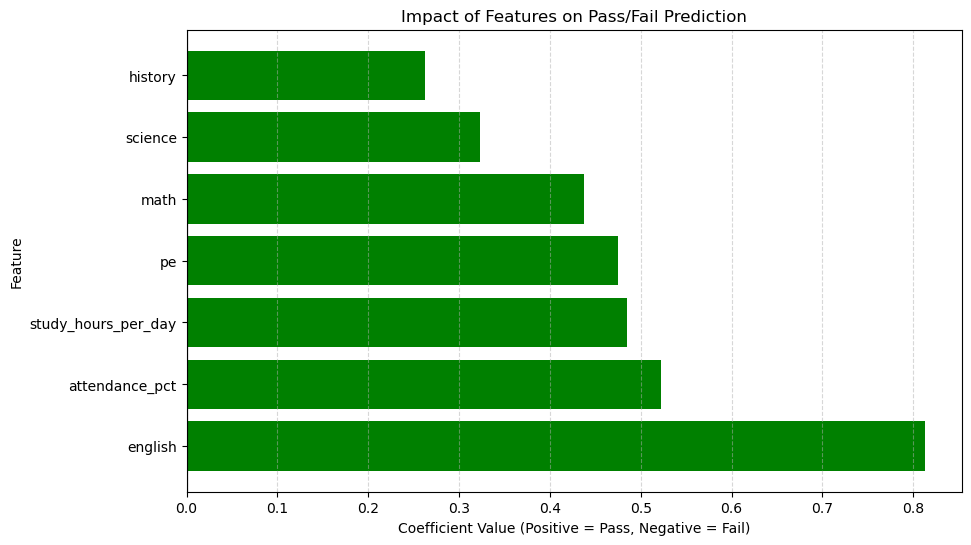

--- New Student Prediction ---
Prediction: Pass
Confidence: 90.8%


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# --- Step 1: Prepare Data ---
# Select only the numeric feature columns (exclude name, passed, and the avg_score we added)
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

# Split: 80% Train, 20% Test (Random state 42 for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling: We fit ONLY on training data to avoid "data leakage"
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Step 2: Train the Model ---
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Training Accuracy
train_acc = model.score(X_train_scaled, y_train)
print(f"Training Accuracy: {train_acc * 100:.1f}%")

# --- Step 3: Evaluate the Model ---
y_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc * 100:.1f}%\n")

print("--- Test Set Predictions ---")
# Accessing names using the index of the test set
test_names = df.loc[X_test.index, 'name']

for i, (name, actual, pred) in enumerate(zip(test_names, y_test, y_pred)):
    status = "✅ correct" if actual == pred else "❌ wrong"
    print(f"{name:<8} | Actual: {actual} | Predicted: {pred} | {status}")

# --- Step 4: Feature Importance ---
# model.coef_[0] gives us the weight of each feature
coefficients = model.coef_[0]
importance_df = pd.DataFrame({'Feature': feature_cols, 'Weight': coefficients})

# Sort by absolute value (largest impact first)
importance_df['Abs_Weight'] = importance_df['Weight'].abs()
importance_df = importance_df.sort_values(by='Abs_Weight', ascending=False)

print("\n--- Feature Coefficients (Sorted by Importance) ---")
print(importance_df[['Feature', 'Weight']])

# Horizontal Bar Chart for Coefficients
plt.figure(figsize=(10, 6))
colors = ['green' if w > 0 else 'red' for w in importance_df['Weight']]
plt.barh(importance_df['Feature'], importance_df['Weight'], color=colors)
plt.axvline(0, color='black', linewidth=0.8) # Reference line at zero
plt.title('Impact of Features on Pass/Fail Prediction')
plt.xlabel('Coefficient Value (Positive = Pass, Negative = Fail)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# --- Step 5: Predict for a New Student ---

# 1. Define the data as a list of lists
new_data = [[75, 70, 68, 65, 80, 82, 3.2]]

# 2. Convert to a DataFrame with the SAME feature names used in X_train
# This removes the "UserWarning" because the names now match perfectly
new_student_df = pd.DataFrame(new_data, columns=feature_cols)

# 3. Scale and Predict
new_student_scaled = scaler.transform(new_student_df)
new_prediction = model.predict(new_student_scaled)[0]
new_probs = model.predict_proba(new_student_scaled)[0]

# 4. Display Result
result = "Pass" if new_prediction == 1 else "Fail"
print("--- New Student Prediction ---")
print(f"Prediction: {result}")
print(f"Confidence: {new_probs[new_prediction]*100:.1f}%")